# Hotel Revenue & Cancellation Analysis

This notebook analyzes hotel booking data to understand revenue performance, cancellation behavior, distribution channel reliability, and basic cancellation prediction.



## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option("display.max_columns", None)

## 2. Data Loading

In [2]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")

print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Data Quality Simulation

Although the original dataset is relatively clean, real-world hotel data often contains missing values, duplicate bookings, inconsistent categories, pricing outliers, and invalid guest values.


In [3]:
np.random.seed(42)

# Missing ADR values
df.loc[df.sample(frac=0.05, random_state=42).index, "adr"] = np.nan

# Duplicate rows
df = pd.concat([df, df.sample(50, random_state=42)], ignore_index=True)

# Inconsistent category naming
df.loc[df.sample(frac=0.05, random_state=42).index, "distribution_channel"] = "booking.com"

# ADR outliers
df.loc[df.sample(frac=0.01, random_state=42).index, "adr"] = df["adr"] * 5

# Invalid adult values
df.loc[df.sample(frac=0.02, random_state=42).index, "adults"] = -1

## 4. Initial Data Inspection

This section checks the structure and quality of the dataset before cleaning.

In [4]:
print("Shape after simulation:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("Duplicate rows:", df.duplicated().sum())

Shape after simulation: (119440, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119440 entries, 0 to 119439
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119440 non-null  object 
 1   is_canceled                     119440 non-null  int64  
 2   lead_time                       119440 non-null  int64  
 3   arrival_date_year               119440 non-null  int64  
 4   arrival_date_month              119440 non-null  object 
 5   arrival_date_week_number        119440 non-null  int64  
 6   arrival_date_day_of_month       119440 non-null  int64  
 7   stays_in_weekend_nights         119440 non-null  int64  
 8   stays_in_week_nights            119440 non-null  int64  
 9   adults                          119440 non-null  int64  
 10  children                        119436 non-null  float64
 11  babies                          119440 non-null  int64  
 12  meal            

None

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119440,119440.000000,119440.000000,119440.000000,119440,119440.000000,119440.000000,119440.000000,119440.000000,119440.000000,119436.000000,119440.000000,119440,118952,119440,119440,119440.000000,119440.000000,119440.000000,119440,119440,119440.000000,119440,103097.000000,6798.000000,119440.000000,119440,113420.000000,119440.000000,119440.000000,119440,119440
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,6,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79365,NaN,NaN,NaN,13881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92348,48608,56502,93037,NaN,NaN,NaN,86032,74087,NaN,104685,NaN,NaN,NaN,89646,NaN,NaN,NaN,75202,1461
mean,NaN,0.370378,104.015916,2016.156455,NaN,27.167406,15.798845,0.927570,2.500385,1.799146,0.103872,0.007945,NaN,NaN,NaN,NaN,0.031899,0.087106,0.137040,NaN,NaN,0.221124,NaN,86.686916,189.244778,2.323610,NaN,105.231806,0.062525,0.571325,NaN,NaN
std,NaN,0.482908,106.863505,0.707473,NaN,13.605984,8.780672,0.998573,1.908177,0.700517,0.398530,0.097416,NaN,NaN,NaN,NaN,0.175732,0.844174,1.497126,NaN,NaN,0.652327,NaN,110.771954,131.657777,17.603417,NaN,65.763134,0.245303,0.792785,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,70.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,178.500000,0.000000,NaN,95.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.670000,0.000000,1.000000,NaN,NaN


Missing values by column:


company                        112642
agent                           16343
adr                              6020
country                           488
children                            4
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
hotel                               0
previous_cancellations              0
days_in_waiting_list                0
customer_type                       0
required_car_parking_spaces         0
total_of_special_requests           0
dtype: int64

Duplicate rows: 29127


## 5. Data Cleaning

The cleaning function below removes duplicates, handles missing values, standardizes categories, creates valid dates, removes invalid guest records, handles ADR outliers, and creates revenue-related variables.


In [5]:
def clean_data(df):
    """
    Clean hotel booking data.

    Steps:
    - remove duplicates
    - handle missing values
    - standardize distribution channel names
    - create arrival date
    - remove invalid guest/night records
    - handle ADR outliers
    - create total price and realized revenue
    """

    df = df.copy()

    # Remove duplicate bookings
    df = df.drop_duplicates()

    # Drop columns with too many missing values / low usefulness for this analysis
    df = df.drop(columns=["agent", "company"])

    # Handle missing values
    df["children"] = df["children"].fillna(0)
    df["country"] = df["country"].fillna("Unknown")

    # Standardize distribution channel names
    df["distribution_channel"] = (
        df["distribution_channel"]
        .str.lower()
        .str.strip()
        .replace({"booking.com": "ta/to"})
    )

    # Create arrival date
    month_map = {
        "January": 1, "February": 2, "March": 3,
        "April": 4, "May": 5, "June": 6,
        "July": 7, "August": 8, "September": 9,
        "October": 10, "November": 11, "December": 12
    }

    df["arrival_month_num"] = df["arrival_date_month"].map(month_map)

    df["arrival_date"] = pd.to_datetime({
        "year": df["arrival_date_year"],
        "month": df["arrival_month_num"],
        "day": df["arrival_date_day_of_month"]
    })

    df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

    df = df.drop(columns=[
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_day_of_month",
        "arrival_month_num"
    ])

    # Remove invalid guest records
    df = df[df["adults"] > 0].copy()
    df = df[(df["adults"] + df["children"] + df["babies"]) > 0].copy()

    # Fill missing ADR by hotel median after invalid guest records are removed
    df["adr"] = df.groupby("hotel")["adr"].transform(lambda x: x.fillna(x.median()))

    # Handle extreme ADR outliers
    upper_limit = df["adr"].quantile(0.99)
    df = df[df["adr"] <= upper_limit].copy()

    # Feature engineering for revenue
    df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
    df = df[df["total_nights"] > 0].copy()

    df["total_price"] = df["adr"] * df["total_nights"]
    df["revenue"] = np.where(df["is_canceled"] == 1, 0, df["total_price"])

    return df

## 6. Feature Engineering

Additional features are created to make analysis easier: month, season, and price group.

In [6]:
def add_features(df):
    """
    Add analysis-friendly features:
    - month
    - season
    - price group
    """
    
    df = df.copy()

    df["month"] = df["arrival_date"].dt.month

    def assign_season(month):
        if month in [7, 8, 9]:
            return "High"
        elif month in [5, 6, 10]:
            return "Mid"
        else:
            return "Low"

    df["season"] = df["month"].apply(assign_season)

    df["price_group"] = pd.cut(
        df["adr"],
        bins=[0, 80, 140, 200, df["adr"].max() + 1],
        labels=["Budget", "Standard", "Premium", "Luxury"],
        include_lowest=True
    )

    return df

In [7]:
df_clean = clean_data(df)
df_final = add_features(df_clean)

print("Final shape:", df_final.shape)
df_final.head()

Final shape: (86171, 34)


,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_nights,total_price,revenue,month,season,price_group
2,Resort Hotel,0,7,27,0,1,1,0.0,0,BB,GBR,Direct,direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,75.0,75.0,7,High,Budget
3,Resort Hotel,0,13,27,0,1,1,0.0,0,BB,GBR,Corporate,corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,75.0,75.0,7,High,Budget
4,Resort Hotel,0,14,27,0,2,2,0.0,0,BB,GBR,Online TA,ta/to,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2,196.0,196.0,7,High,Standard
6,Resort Hotel,0,0,27,0,2,2,0.0,0,BB,PRT,Direct,direct,0,0,0,C,C,0,No Deposit,0,Transient,107.0,0,0,Check-Out,2015-07-03,2015-07-01,2,214.0,214.0,7,High,Standard
7,Resort Hotel,0,9,27,0,2,2,0.0,0,FB,PRT,Direct,direct,0,0,0,C,C,0,No Deposit,0,Transient,103.0,0,1,Check-Out,2015-07-03,2015-07-01,2,206.0,206.0,7,High,Standard


In [8]:
df_final.to_csv("../data/processed/hotel_bookings_clean.csv", index=False)

## 7. SQL Setup

The cleaned dataframe is saved into a SQLite database so SQL can be used for business analysis.

In [9]:
conn = sqlite3.connect("../sql/hotel_booking.db")

df_final.to_sql(
    "bookings",
    conn,
    if_exists="replace",
    index=False
)

86171

## 8. SQL Analysis: Hotel Performance

This query compares hotels by total bookings, total realized revenue, ADR, and cancellation rate.

In [10]:
query = """
SELECT
    hotel,
    COUNT(*) AS total_bookings,
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(AVG(adr), 2) AS avg_adr,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
FROM bookings
GROUP BY hotel
ORDER BY total_revenue DESC;
"""

hotel_performance = pd.read_sql(query, conn)
hotel_performance

,hotel,total_bookings,total_revenue,avg_adr,cancellation_rate
0,City Hotel,53452,11986282.81,110.42,31.04
1,Resort Hotel,32719,10070441.20,95.08,23.71


### Insight: Hotel Performance

City hotels generate higher revenue due to higher booking volume and stronger ADR. However, their higher cancellation rate suggests that part of this demand is less reliable and may create revenue-management uncertainty.

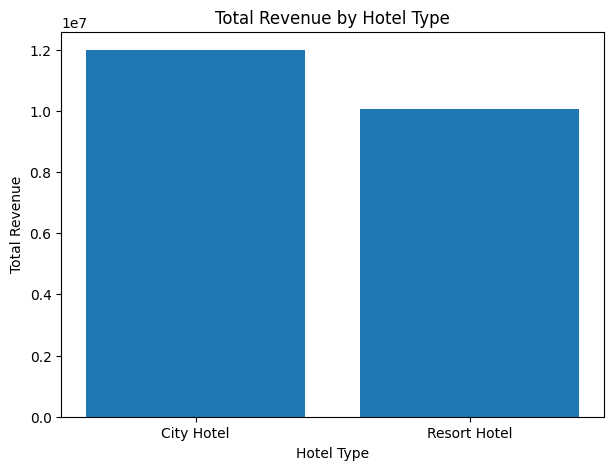

In [11]:
plt.figure(figsize=(7, 5))
plt.bar(hotel_performance["hotel"], hotel_performance["total_revenue"])
plt.title("Total Revenue by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Total Revenue")
plt.show()

## 9. SQL Analysis: Distribution Channel Performance

This query compares revenue and cancellation risk across distribution channels.

In [12]:
query = """
SELECT
    distribution_channel,
    COUNT(*) AS total_bookings,
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
FROM bookings
GROUP BY distribution_channel
ORDER BY total_revenue DESC;
"""

distribution_channel_performance = pd.read_sql(query, conn)
distribution_channel_performance

,distribution_channel,total_bookings,total_revenue,cancellation_rate
0,ta/to,69188,17777340.74,31.63
1,direct,11955,3575485.28,14.91
2,corporate,4851,673108.31,13.17
3,gds,172,30226.17,20.35
4,undefined,5,563.50,80.00


### Insight: Distribution Channel Performance

Intermediary channels generate strong booking volume and revenue, but they also carry higher cancellation risk. Direct and corporate channels may produce lower volume, but they are more stable and predictable.

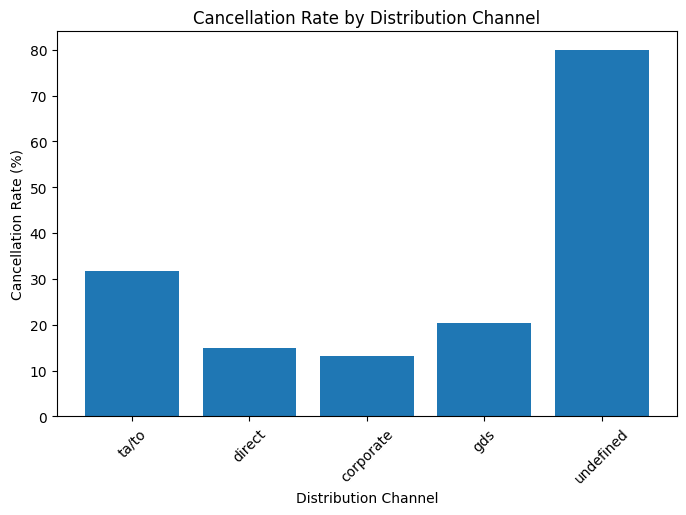

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(distribution_channel_performance["distribution_channel"],distribution_channel_performance["cancellation_rate"])
plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 10. SQL Analysis: Lead Time and Cancellation

This query groups bookings by lead time to understand how far-in-advance bookings affect cancellation risk.

In [14]:
query = """
SELECT
    CASE
        WHEN lead_time < 7 THEN '0-7 days'
        WHEN lead_time < 30 THEN '7-30 days'
        WHEN lead_time < 90 THEN '30-90 days'
        ELSE '90+ days'
    END AS lead_time_group,
    COUNT(*) AS total_bookings,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
FROM bookings
GROUP BY lead_time_group
ORDER BY cancellation_rate DESC;
"""

lead_time_cancellation = pd.read_sql(query, conn)
lead_time_cancellation

,lead_time_group,total_bookings,cancellation_rate
0,90+ days,30646,37.87
1,30-90 days,22595,32.40
2,7-30 days,16592,24.47
3,0-7 days,16338,8.34


### Insight: Cancellation vs Lead Time

Cancellation rates increase significantly with lead time. Long lead-time bookings may help hotels forecast demand earlier, but they are also less reliable.

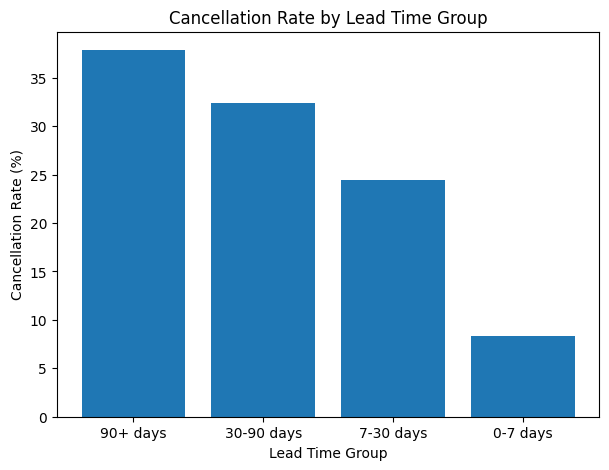

In [15]:
plt.figure(figsize=(7, 5))
plt.bar(lead_time_cancellation["lead_time_group"],lead_time_cancellation["cancellation_rate"])
plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 11. Machine Learning: Booking Cancellation Prediction

This section is exploratory. The goal is not to create a production-ready model, but to test whether available booking features can help identify cancellations.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y = df_final["is_canceled"]

features = [
    "lead_time",
    "country",
    "market_segment",
    "is_repeated_guest",
    "deposit_type",
    "total_of_special_requests",
    "hotel"
]

X = df_final[features]
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Accuracy = 0.7142967662076435
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.68      0.77     18547
           1       0.50      0.81      0.62      7305

    accuracy                           0.71     25852
   macro avg       0.70      0.74      0.69     25852
weighted avg       0.79      0.71      0.73     25852

Confusion Matrix: [[12553  5994]
 [ 1392  5913]]


### Feature Importance

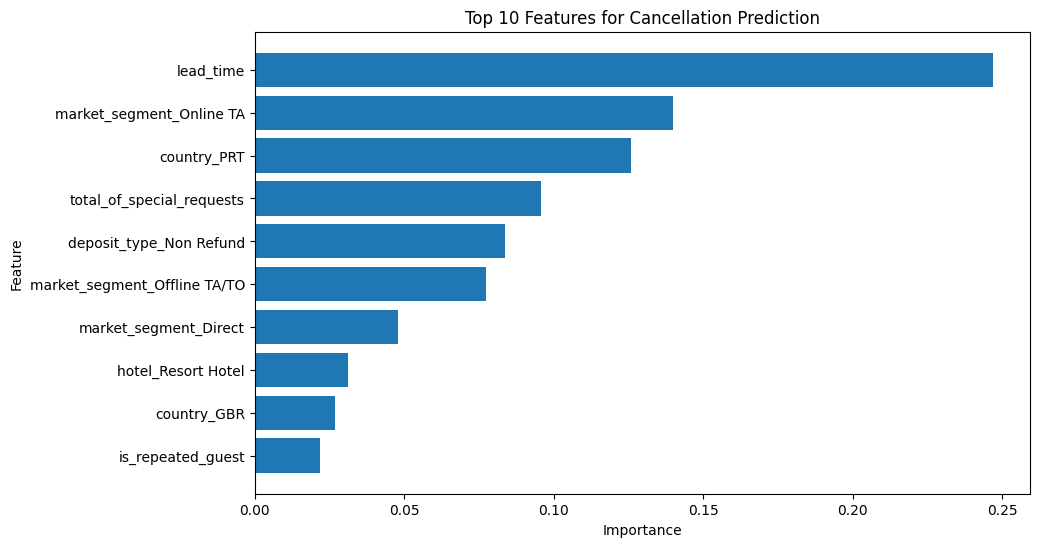

In [17]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 10 Features for Cancellation Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Machine Learning Conclusion

The balanced model improves the ability to detect cancellation cases compared with a model optimized only for accuracy. However, this can increase false positives. In a hotel context, this may still be useful because identifying risky bookings early can support overbooking strategy, guest communication, and revenue planning.

## 12. Final Insights

- City hotels generate more total revenue, but their demand is less stable because cancellation rates are higher.
- TA/TO channels produce high booking volume and revenue, but also carry higher cancellation risk.
- Direct and corporate channels appear more stable and may be valuable for revenue reliability.
- Long lead-time bookings are much more likely to cancel than last-minute bookings.
- Cancellation prediction can be useful, but the model should be evaluated with recall and false positives, not accuracy alone.

## 13. Business Recommendations

- Encourage more direct bookings through incentives such as better flexibility, small perks, or loyalty benefits.
- Monitor long lead-time bookings as higher-risk reservations.
- Track revenue and cancellation rate together instead of looking at revenue alone.
- Use cancellation-risk signals to support overbooking and revenue management decisions.
- Continue improving the model with more features and validation before using it for real decisions.

In [18]:
df_final.to_csv("../data/processed/hotel_bookings_final.csv", index=False)
conn.close()